# Task 1: Problem Identification

## Identify what type of computer vision problem the dataset represents.

### Selected Problem Type:
- Image Classification


## Clearly explain why the selected problem type is appropriate for the dataset.

The dataset represents an **image classification** problem because:

- The dataset contains images organized into different class folders.
- Each image belongs to only one category/class.
- The objective is to predict the correct class label for an input image.
- There are no bounding boxes or segmentation masks provided in the dataset.

Since the task involves assigning a single label to each image, image classification is the most appropriate computer vision problem type.


## Why Other Problem Types Do Not Apply

### Object Detection
Object detection requires:
- Bounding boxes around objects
- Localization of objects inside images

The dataset does not contain bounding box annotations.


### Semantic Segmentation
Semantic segmentation requires:
- Pixel-level classification
- Segmentation masks for each image

The dataset does not provide segmentation masks.


### Instance Segmentation
Instance segmentation requires:
- Detection of multiple object instances
- Pixel-wise masks for each object

No instance-level annotations are available in the dataset.

## Final Conclusion

Therefore, the selected computer vision problem type for this dataset is:

# Image Classification

Classes: ['dent', 'normal', 'scratch', 'stain']
Number of classes: 4

Number of images per class:
dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


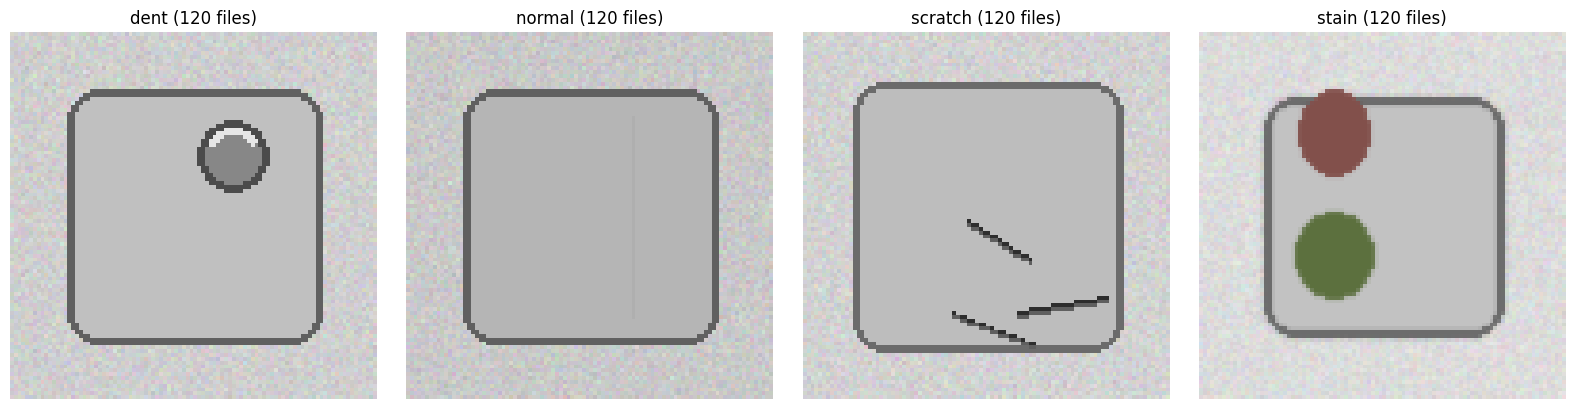


Image Dimensions:
dent: (96, 96)
normal: (96, 96)
scratch: (96, 96)
stain: (96, 96)

Dataset Imbalance Check:
Maximum images in a class: 120
Minimum images in a class: 120
Dataset appears relatively balanced.


In [1]:
# Task 2: Dataset Exploration

import os
from PIL import Image
import matplotlib.pyplot as plt
import random
import math

# Path to dataset
data_dir = "images"


classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

# Number of classes
print("Classes:", classes)
print("Number of classes:", len(classes))


# Number of images per class
print("\nNumber of images per class:")
image_counts = []

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    valid_images = [img for img in os.listdir(class_path) if not img.startswith('.')]
    num_images = len(valid_images)
    
    image_counts.append(num_images)
    print(f"{cls}: {num_images} images")


# Sample images from each class

num_classes = len(classes)
cols = 4  # Fix the number of columns to 4 for clean alignment
rows = math.ceil(num_classes / cols)  # Calculate rows needed to fit all classes

# Adjust figure size dynamically based on the number of rows
plt.figure(figsize=(16, 4 * rows))

for i, cls in enumerate(classes):
    class_path = os.path.join(data_dir, cls)
    valid_images = [img for img in os.listdir(class_path) if not img.startswith('.')]
    
    if not valid_images:
        print(f"Warning: No valid images found in folder '{cls}'")
        continue

    random_image = random.choice(valid_images)
    img_path = os.path.join(class_path, random_image)

    img = Image.open(img_path)

    # Uses the dynamically calculated rows and columns
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"{cls} ({image_counts[i]} files)")
    plt.axis("off")

plt.tight_layout()
plt.show()


#Image dimensions
print("\nImage Dimensions:")
for cls in classes:
    class_path = os.path.join(data_dir, cls)
    valid_images = [img for img in os.listdir(class_path) if not img.startswith('.')]
    
    if not valid_images:
        continue
        
    sample_image = random.choice(valid_images)
    img_path = os.path.join(class_path, sample_image)

    img = Image.open(img_path)
    print(f"{cls}: {img.size}")


# Any imbalance in the dataset
print("\nDataset Imbalance Check:")

image_counts = []

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    count = len(os.listdir(class_path))

    image_counts.append(count)

max_images = max(image_counts)
min_images = min(image_counts)

print("Maximum images in a class:", max_images)
print("Minimum images in a class:", min_images)

if max_images - min_images > 50:
    print("Dataset appears imbalanced.")
else:
    print("Dataset appears relatively balanced.")

In [2]:
# Task 3: Image Preprocessing

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


data_dir = "images"

# Resizing images to a fixed size
IMG_HEIGHT = 128
IMG_WIDTH = 128


# Normalizing pixel values

train_datagen = ImageDataGenerator(
    rescale=1./255
)

# Splitting into training and testing sets
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

BATCH_SIZE = 32

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Applying augmentation, if needed
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Display Dataset Information
print("Training Images:", train_data.samples)
print("Testing Images:", test_data.samples)

print("Image Shape:", train_data.image_shape)


Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Training Images: 384
Testing Images: 96
Image Shape: (128, 128, 3)


In [3]:
# Task 4: CNN Model Creation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

# Building the CNN Model
model = Sequential()


# Convolution Layer + Activation Function
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))


# Second Convolution + Pooling
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))


# Third Convolution + Pooling
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())


# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(len(classes), activation='softmax'))


# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Model Summary
model.summary()

c:\Users\Pernytha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 525ms/step - accuracy: 0.2578 - loss: 1.4463 - val_accuracy: 0.2500 - val_loss: 1.3256
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 423ms/step - accuracy: 0.4323 - loss: 1.1825 - val_accuracy: 0.6354 - val_loss: 1.0133
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step - accuracy: 0.7057 - loss: 0.7832 - val_accuracy: 0.7812 - val_loss: 0.6015
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 449ms/step - accuracy: 0.7656 - loss: 0.5778 - val_accuracy: 0.7812 - val_loss: 0.6042
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - accuracy: 0.8776 - loss: 0.3614 - val_accuracy: 0.9167 - val_loss: 0.2686
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 424ms/step - accuracy: 0.9531 - loss: 0.1844 - val_accuracy: 0.9375 - val_loss: 0.1345
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - accuracy: 0.9740 - loss: 0.1221 - val_accuracy: 0.9479 - val_loss: 0.1435
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 440ms/step - accuracy: 0.9818 - loss: 0.0759 - val_accuracy: 0

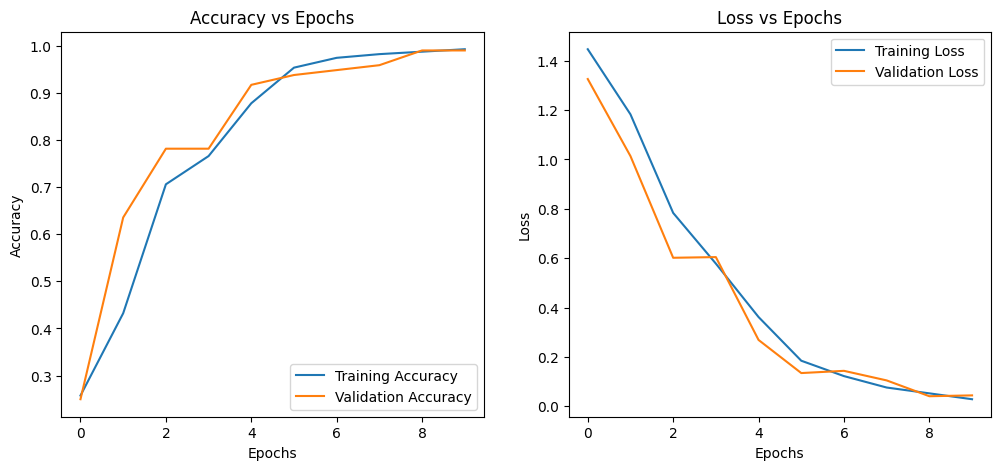

Final Validation Accuracy: 0.9895833134651184
Final Validation Loss: 0.04400774836540222
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9896 - loss: 0.0440
Test Loss: 0.04400774836540222
Test Accuracy: 0.9895833134651184
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


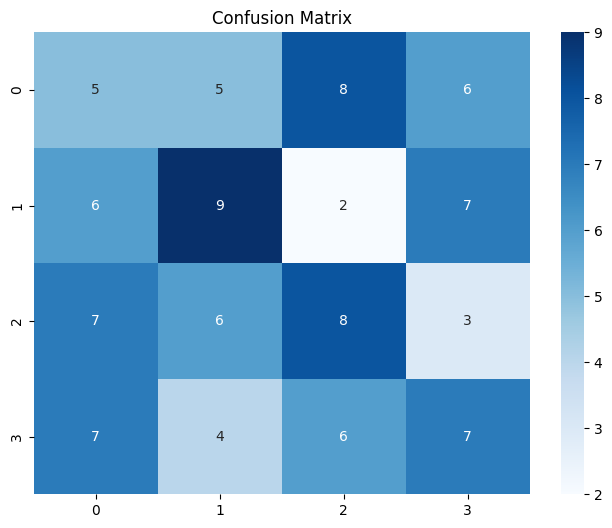

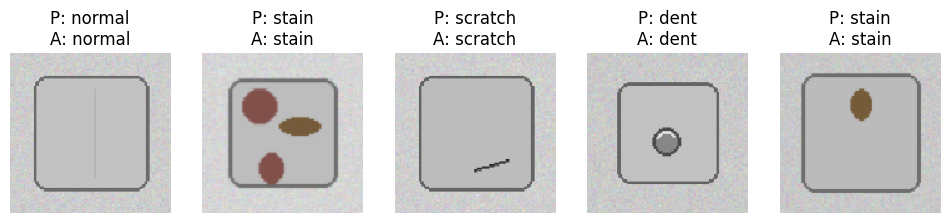

In [4]:
# Task 5: Model Training and Evaluation

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix


#  Model Training
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

#  Training & Validation Accuracy/Loss Graphs
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

# Final Validation Accuracy & Loss
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

# Test Performance

test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Confusion Matrix
predictions = model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.savefig("results/confusion_matrix.png")

plt.show()

# Sample Predictions on test images
class_labels = list(test_data.class_indices.keys())

images, labels = next(test_data)

plt.figure(figsize=(12,6))

for i in range(5):
    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    prediction = model.predict(
        np.expand_dims(images[i], axis=0),
        verbose=0
    )

    predicted_class = class_labels[np.argmax(prediction)]
    actual_class = class_labels[np.argmax(labels[i])]

    plt.title(f"P: {predicted_class}\nA: {actual_class}")
    plt.axis('off')

plt.savefig("sample_predictions/prediction_outputs.png")
plt.show()


# Task 6: CNN Concept Explanation

## What is Convolution?

Convolution is a process where a small filter (kernel) moves across an image to extract important features such as edges, textures, and patterns.  
It helps the model understand visual structures in an image.


## Why is Pooling used?

Pooling is used to reduce the spatial size of feature maps while keeping important information.

It helps in:
- Reducing computation cost
- Preventing overfitting
- Making the model more efficient


## Why is ReLU commonly used in CNNs?

ReLU (Rectified Linear Unit) is used as an activation function because:

- It introduces non-linearity
- It helps the model learn complex patterns
- It avoids the vanishing gradient problem
- It speeds up training

ReLU converts negative values to zero and keeps positive values unchanged.


## Why are CNNs better than regular feed-forward networks for image data?

CNNs are better because:

- They preserve spatial relationships in images
- They use shared weights, reducing the number of parameters
- They automatically learn features (edges → shapes → objects)
- They are more efficient for high-dimensional image data

In contrast, feed-forward networks treat all pixels independently and lose spatial structure.


# Task 7: Business Use Case Mapping

## Real-World Application: Healthcare (Medical Imaging)

A CNN-based image classification system can be applied in the healthcare domain for analyzing medical images such as X-rays, CT scans, and MRI scans.


## How it is used:

- Detect diseases such as pneumonia, tumors, or fractures from medical images
- Classify scans into normal or abnormal categories
- Assist doctors in faster and more accurate diagnosis


## Benefits:

- Faster diagnosis compared to manual inspection
- Reduces human error in medical interpretation
- Helps doctors prioritize critical cases
- Scalable solution for hospitals and diagnostic centers


## Conclusion:

This CNN-based image classification model demonstrates how deep learning can support healthcare professionals by improving accuracy and efficiency in medical image analysis.